# <span style="color:#0b486b">STAT1121/8721 - Data Science - Assignment 1 Part II</span>

---
Topic coordinator: Sergiy Shelyag | sergiy.shelyag@flinders.edu.au<br />

College of Science and Engineering, <br />
Flinders University.

---

### <span style="color:#0b486b">Instructions</span>

This notebook has been prepared for you to complete Part II of Assignment 1. Some sections have been pre-filled  to help you get started. **The total mark for this programming task is 65**.

1. Before you start, read the entire notebook carefully to understand what you need to do. You should also refer to the main instructions in *Assignment1_instructions.pdf*  to know what else you need to complete for this assignment.
2. For each cell marked with *#INSERT YOUR CODE HERE*, you must write your own code in this cell.
3. For each cell marked with *#INSERT YOUR COMMENT HERE*, you must write your own explanatory comment in this cell.
4. At the end, you must run the entire notebook and submit two files:
 1. The source of your solution notebook: [YourID]_assignment1_solution.ipynb
 2. And an exported version of your output: [YourID]_assignment1_output.html  
       
For example, if your student ID is 123456, then you need submit two files:

1. **123456_assignment1_solution.ipynb**
2. and **123456_assignment1_output.html**

As you go through this notebook:

* markdown cells marked with **Note** mean description sections.
* markdown cells marked with **Instructions** mean the instructions given to you to complete the sections.

***If an instruction is not clear, please contact the unit chair or the teaching team as soon as possible.***


In [14]:
#
#Import packages needed for processing
#
import numpy as np   # import the numpy package
import csv           # this package needed for processing csv file
from collections import Counter  # this is for dictionary construction with counting functionality
import matplotlib.pyplot as plt  # this is for plotting and other descriptive statistics
import datetime      # this package is for handling time
#
#If you need add any additional packages, then add them below this line
#



**Note**: you must place your data file in the same folder with your python notebook.

In [15]:
# Declare the path to the data file
DATA_FILE = "/Users/siddu/Desktop/Assignment1/compact.csv"

**Note**. The following segment of codes is to load the data from the .csv file using csv package. It has been provided for you to get started. Please **do not** change this piece of code as well the variable names as we will need these variables to complete subsequent tasks. 

In [16]:
# Load CSV file using DictReader
input_file = csv.DictReader(open(DATA_FILE))
fieldnames = input_file.fieldnames
data_dict = {fn: [] for fn in fieldnames}
print(data_dict.keys())
for line in input_file:
    for k, v in line.items():
        if (v == ''): #quick fix for missing values
            v=0
        try:
            data_dict[k].append(int(v))
        except ValueError:
            try:
                data_dict[k].append(float(v))
            except ValueError:
                data_dict[k].append(v)
                
for k, v in data_dict.items():
    data_dict[k] = np.array(v)

dict_keys(['country', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'excess_mortality', 'excess_mortality_cumulative', 'excess_mortality_cumulative_absolute', 'excess_mortality_cumulative_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'icu_patients', 'icu_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'stringency_index', 'reproduction_rate', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_s

---
## **Instruction 1**
We first examine the variables and the overall data size. The tasks:

1. Write your code to print the type for the following variables (**4 marks**):
    * input_file
    * data_dict
    * data_dict['code']
    * data_dict['reproduction_rate']


2. Write your code to print out the number of data records (**1 mark**):

[**Total mark: 5**]

In [17]:
# INSERT YOUR CODE HERE
#
#1. Write you code to print the type for the following variables:
#    * input_file
#    * data_dict
#    * data_dict['code']
#    * data_dict['reproduction_rate']
#
print(type(input_file))
print(type(data_dict))
print(type(data_dict['code']))
print(type(data_dict['reproduction_rate']))


<class 'csv.DictReader'>
<class 'dict'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [18]:
# INSERT YOUR CODE HERE
#
# 2. Write your code to print out the number of data records
#
# number of rows in dataset

print(len(data_dict))

61


---
## Instruction 2
The following code segment is designed to calculate some basic statistics from the data for a recent date. The data is stored in **data_filtered_by_date** dictionary.

**Your task:**
1. Learn how the code, which extracts the data for all countries at a required date, works. Why **try-except** construction is required in this code? Provide the answer. (**2 marks**)
1. Write your code to find and print the minimum and the maximum values of mortality per million in the **total_deaths_per_million** column. (**1 mark**)
2. Write your code to find and print the minimum and the maximum values of cases per million in the **total_cases_per_million** column. (**1 mark**)
3. Write your code to find and print the mean and median mortality per million, and the standard deviation from the **total_deaths_per_million** column. (**2 marks**)
4. Write your code to construct a box plot for the **total_deaths_per_million**. (**2 marks**) 
4. You will find that mean and median values for mortality are quite different. Briefly describe the meaning of the difference between the mean and median mortality per million. Why are they different? (**2 marks**)

**[Total mark: 10]**

In [19]:
# THIS PART EXTRACTS THE DATA FOR ALL COUNTRIES AT A REQUIRED DATE.
# LEARN HOW IT WORKS.
# data_filtered_by_date DICTIONARY CONTAINS ALL DATA FOR ALL COUNTRIES AT required_date

required_date = '2021-03-09'

index_for_date = (data_dict['date'] == required_date)
data_filtered_by_date = {}
for key in data_dict.keys():
    try:
        data_filtered_by_date[key] = np.float_(data_dict[key][index_for_date])
    except:
        data_filtered_by_date[key] = data_dict[key][index_for_date]

In [20]:
# 1. Why **try-except** construction is required in this code? (2 marks)
# The try-except is used because not all columns are numeric. 
# Some columns like country or continent are text, so converting them to float will give error. 
# Try-except avoids stopping the code and handles both numeric and non-numeric data.

In [21]:
# Ensure that the data_filtered_by_date variable is defined before this cell
required_date = '2021-03-09'

index_for_date = (data_dict['date'] == required_date)
data_filtered_by_date = {}
for key in data_dict.keys():
    try:
        data_filtered_by_date[key] = np.float_(data_dict[key][index_for_date])
    except:
        data_filtered_by_date[key] = data_dict[key][index_for_date]


In [22]:
# INSERT YOUR CODE HERE
#
# 3. Write your code to find and print the minimum and the maximum values of cases per million 
# in the total_cases_per_million column. (1 mark)
#
cases_pm = data_filtered_by_date['total_cases_per_million']

print("min cases per million:", np.min(cases_pm))
print("max cases per million:", np.max(cases_pm))

min cases per million: 0.0
max cases per million: 138844.98


In [23]:
# Ensure that the data_filtered_by_date variable is defined before this cell
deaths_pm = data_filtered_by_date['total_deaths_per_million']

# INSERT YOUR CODE HERE
# Write your code to find and print the mean and median mortality per million, and the standard 
# deviation from the total_deaths_per_million column. (2 marks)
print("mean:", np.mean(deaths_pm))
print("median:", np.median(deaths_pm))
print("std deviation:", np.std(deaths_pm))

mean: 407.55485212642026
median: 119.49049
std deviation: 584.4432492924736


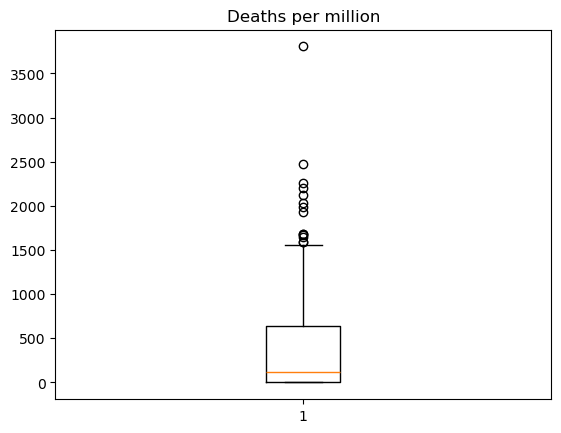

In [24]:
# INSERT YOUR CODE HERE
#
# Write your code to construct a box plot for the COVID mortality per million.
#
import matplotlib.pyplot as plt

plt.boxplot(deaths_pm)
plt.title("Deaths per million")
plt.show()


In [25]:
# INSERT YOUR COMMENT HERE
# Briefly describe the meaning of the difference between the mean and median COVID mortality per million.
# Why are they different? (2 marks)

# Answer :-

# The mean and median are different because the data is not evenly distributed.
# Some countries have very high death rates which increase the mean value.
# The median is less affected by extreme values, so it stays lower.
# This shows the data is skewed.


---
## **Instruction 3**
This part of the assignment is designed to examine COVID cases and mortality data for different countries. The countries are given by their ISO alpha-3 codes, given here: https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3 .
As in the previous task, we will be using **total_cases_per_million** and **total_deaths_per_million** columns.

**Your tasks**:

1. Write your code to find and print out the number of countries in the dataset. (**1 mark**)
2. Population mortality from seasonal influenza is generally thought to be about 0.01% (1 death per 10000 people). Write your code to find and print out the list of countries with the population mortality greater than ten times of the population mortality of seasonal influenza. (**2 marks**)
3. Write your code to find and print out the country with the highest population mortality. Both the country code and the mortality value for this country need to be printed out (**2 marks**)
4. Write your code to construct a dictionary variable ***data_large_countries*** whose keys are **code**, **total_cases_per_million**, **total_deaths_per_million**, **population**, **population_density**. You can start from the original dataset **data_dict**. You can adapt the code given to you in Instruction 2. Print the dictionary. (**2 marks**)
5. Using the new dictionary ***data_large_countries***, plot a bar chart of mortality sorted in descending order of values for the countries with **population** more than 1 million, achieving first twenty places of leadership in exterminating their own population. (**3 marks**)
6. Using the same dictionary, plot a bar chart of population density for the mortality leaders. Use the same order of countries as in Task 5. (**3 marks**)
7. Discuss the bar charts. Which conclusion you can draw, if you look at all of them together? (**2 marks**)

[**Total mark: 15**]

In [26]:
# INSERT YOUR CODE HERE 
# Write your code to find and print out the number of countries in the dataset. (1 mark)
# To be sure that you get a list of unique countries, you may want to use np.unique
codes = np.unique(data_dict['code'])
print("number of countries:", len(codes))


number of countries: 248


In [27]:
# INSERT YOUR CODE HERE 
#
# 2. Population mortality from seasonal influenza is generally thought to be about 0.01% 
# (1 death per 10000 people). Write your code to find and print out the list of countries 
# with the population mortality is more than ten times of the seasonal influenza. (2 marks)
#
deaths_pm = data_dict['total_deaths_per_million']

# convert per million to percentage
mortality_rate = deaths_pm / 1_000_000

high_mortality = data_dict['code'][mortality_rate > 0.001]

print(np.unique(high_mortality))

['0' 'ABW' 'ALB' 'AND' 'ARG' 'ARM' 'ATG' 'AUT' 'AZE' 'BEL' 'BES' 'BGR'
 'BHR' 'BHS' 'BIH' 'BLZ' 'BMU' 'BOL' 'BRA' 'BRB' 'BWA' 'CAN' 'CHE' 'CHL'
 'COL' 'CRI' 'CUW' 'CYP' 'CZE' 'DEU' 'DMA' 'DNK' 'ECU' 'ESP' 'EST' 'FIN'
 'FRA' 'GBR' 'GEO' 'GGY' 'GIB' 'GLP' 'GRC' 'GRD' 'GTM' 'GUF' 'GUM' 'GUY'
 'HND' 'HRV' 'HUN' 'IMN' 'IRL' 'IRN' 'ISR' 'ITA' 'JAM' 'JEY' 'JOR' 'LBN'
 'LCA' 'LIE' 'LTU' 'LUX' 'LVA' 'MAF' 'MCO' 'MDA' 'MEX' 'MKD' 'MLT' 'MNE'
 'MSR' 'MTQ' 'MYS' 'NAM' 'NCL' 'NLD' 'NOR' 'OWID_EU27' 'OWID_EUR'
 'OWID_KOS' 'OWID_NAM' 'OWID_SAM' 'PAN' 'PER' 'POL' 'PRI' 'PRT' 'PRY'
 'PSE' 'PYF' 'REU' 'ROU' 'RUS' 'SMR' 'SRB' 'SUR' 'SVK' 'SVN' 'SWE' 'SWZ'
 'SXM' 'SYC' 'TTO' 'TUN' 'TUR' 'UKR' 'URY' 'USA' 'VCT' 'VGB' 'VIR' 'ZAF']


In [28]:
# INSERT YOUR CODE HERE 
# Write your code to find and print out the country with the highest population mortality. 
# Both the country code and the mortality value for this country need to be printed out (2 marks)
# HINT: You can use np.where or np.argmax functions.
idx = np.argmax(deaths_pm)

print("country:", data_dict['code'][idx])
print("max mortality:", deaths_pm[idx])


country: PER
max mortality: 6603.8574


In [29]:
# INSERT YOUR CODE HERE 
# 4. Write your code to construct a dictionary variable ***data_large_countries*** whose keys are **code**,
# **total_cases_per_million**, **total_deaths_per_million**, **population**, **population_density**.
# You can start from the original dataset **data_dict**.
# You can adapt the code given to you in Instruction 2.
# Print the dictionary.
# (**2 marks**)
data_large_countries = {}

keys = ['code', 'total_cases_per_million', 'total_deaths_per_million',
        'population', 'population_density']

for key in keys:
    data_large_countries[key] = data_dict[key]

print(data_large_countries)


{'code': array(['AFG', 'AFG', 'AFG', ..., 'ZWE', 'ZWE', 'ZWE'], dtype='<U21'), 'total_cases_per_million': array([    0.   ,     0.   ,     0.   , ..., 16580.682, 16580.682,
       16580.682]), 'total_deaths_per_million': array([  0.    ,   0.    ,   0.    , ..., 357.2082, 357.2082, 357.2082]), 'population': array([40578847, 40578847, 40578847, ..., 16069061, 16069061, 16069061]), 'population_density': array([62.21554947, 62.21554947, 62.21554947, ..., 41.53822327,
       41.53822327, 41.53822327])}


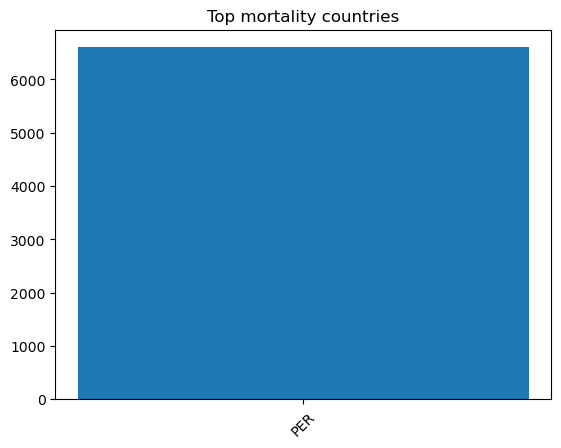

In [30]:
# INSERT YOUR CODE HERE 
# 5. Using the new dictionary ***data_large_countries***, plot a bar chart of mortality
# sorted in descending order of values for the countries with **population** more than 1 million, 
# achieving first twenty places in exterminating their own population. (**3 marks**)
#
# HINT: You can use np.argsort.
# filter population > 1M
pop = data_large_countries['population']
deaths = data_large_countries['total_deaths_per_million']
codes = data_large_countries['code']

# taking countries with population > 1M
mask = pop > 1000000

codes_f = codes[mask]
deaths_f = deaths[mask]

# removing missing values
good = ~np.isnan(deaths_f)
codes_f = codes_f[good]
deaths_f = deaths_f[good]

# sorting
order = np.argsort(deaths_f)[::-1]

top_codes = codes_f[order][:20]
top_deaths = deaths_f[order][:20]

plt.figure()
plt.bar(top_codes, top_deaths)
plt.xticks(rotation=45)
plt.title("Top mortality countries")
plt.show()

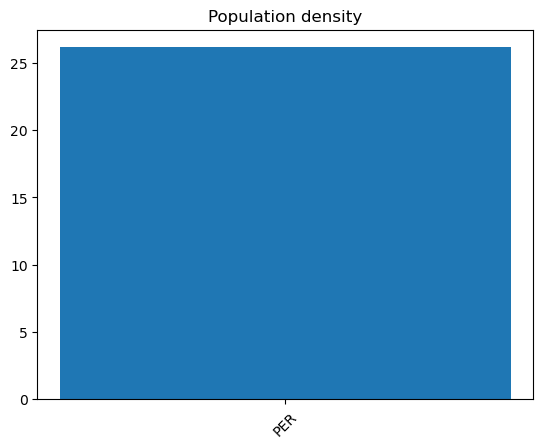

In [31]:
# INSERT YOUR CODE HERE 
# 6. Using the same dictionary, plot a of total cases and population density for the mortality leaders.
# Use the same order of countries as in Task 5. (**3 marks**)
#
# HINT: you want to plot these side by side.
# get population density
density = data_large_countries['population_density'][mask]

# same filtering
density = density[good]

top_density = density[order][:20]

plt.figure()
plt.bar(top_codes, top_density)
plt.xticks(rotation=45)
plt.title("Population density")
plt.show()

In [32]:
# 7. Discuss the bar charts. Which conclusion you can draw, if you look at all of them together? (**2 marks**)
# INSERT YOUR COMMENT HERE
#
# From the charts, countries with high mortality are not always the most densely populated.
# Some countries with moderate density also have high death rates.
# This shows that population density alone does not explain mortality.
# Other factors like healthcare and policies also matter.

---
## **Instruction 4**
Let's now look at the other end of the COVID spread - at the countries with large populations (more than 1 million) and with the minimal number of cases and deaths. We can use the same dataset ***data_large_countries*** we have prepared in the previous task.

**Your tasks here are:**
1. Using the new dictionary ***data_large_countries***, plot bar charts of mortality per million, cases per million and population density for the 20 countries with **population** more than 1 million and minimal mortality. (**3 marks**)
2. In the bar charts you have got you should see a very clear exception. Describe its properties. What makes it exceptional? (**2 marks**)

[**Total mark: 5**]

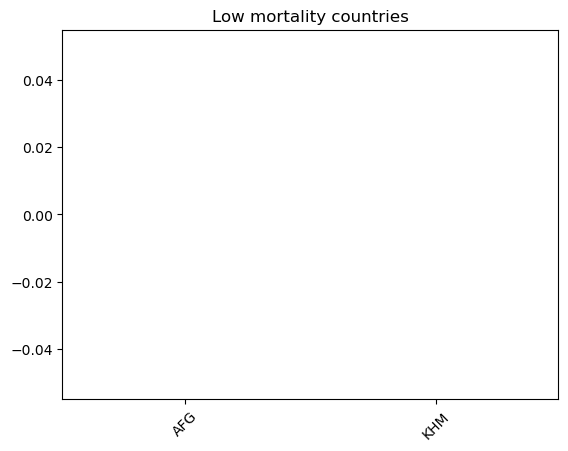

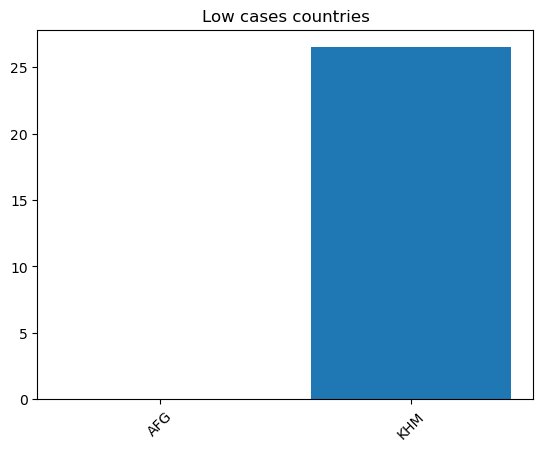

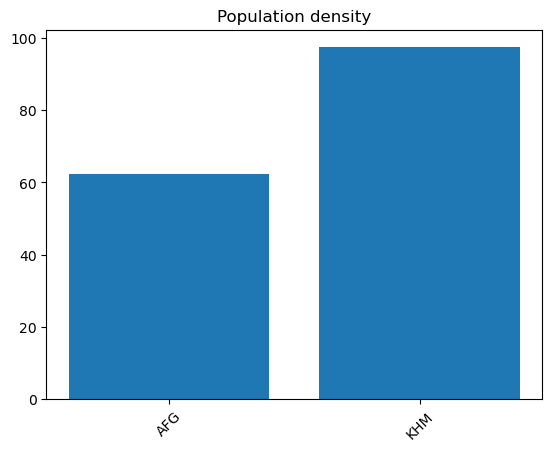

In [33]:
# 1. Using the new dictionary ***data_large_countries***, plot bar charts of mortality per million, 
# cases per million and population density for the 20 countries with **population** more than 1 
# million and minimal mortality. (**3 marks**)
#INSERT YOUR CODE HERE
pop = data_large_countries['population']
deaths = data_large_countries['total_deaths_per_million']
cases = data_large_countries['total_cases_per_million']
density = data_large_countries['population_density']
codes = data_large_countries['code']

# population > 1M
mask = pop > 1000000

codes_f = codes[mask]
deaths_f = deaths[mask]
cases_f = cases[mask]
density_f = density[mask]

# remove missing
ok = ~np.isnan(deaths_f)
codes_f = codes_f[ok]
deaths_f = deaths_f[ok]
cases_f = cases_f[ok]
density_f = density_f[ok]

# sort ascending (small values)
order = np.argsort(deaths_f)

top_codes = codes_f[order][:20]
top_deaths = deaths_f[order][:20]
top_cases = cases_f[order][:20]
top_density = density_f[order][:20]

# mortality plot
plt.figure()
plt.bar(top_codes, top_deaths)
plt.xticks(rotation=45)
plt.title("Low mortality countries")
plt.show()

# cases plot
plt.figure()
plt.bar(top_codes, top_cases)
plt.xticks(rotation=45)
plt.title("Low cases countries")
plt.show()

# density plot
plt.figure()
plt.bar(top_codes, top_density)
plt.xticks(rotation=45)
plt.title("Population density")
plt.show()

In [34]:
# 2. In the bar charts you have got you should see a very clear exception. Describe its properties. 
# What makes it exceptional? (**2 marks**)
# INSERT YOUR COMMENT HERE
#
# One country stands out because it has very low mortality and cases compared to others.
# Even though some countries have higher population or density, this country still has very low values.
# This may be due to strict control measures, better policies, or less reporting.

---
## **Instruction 5 (HD/GE level)**

We will return back to the differences between the countries in their ways of dealinig with epidemics in Instruction 6. Now, however, we shall look at the basics of epidemiological processes from the point of view
of real data. Generally, epidemics evolve exponentially until they are either stopped by some measures (lockdowns, vaccinations) or saturate (population dies out and/or gets naturally immune).

**Your tasks**:

1. Define a function called **convert_date** that takes date string (in the format as it is given in the dataset csv file) as the input and returns the number of days from that date until now. The number should be negative. For example, today is 14/3/21. The input date is 3/3/21. The function should compute the difference between the input date and today's date and return -13. If the function argument is in incorrect form, the function should return 0. Don't forget to test it. (**4 marks**)
2. Pick three countries, which may be interesting or relevant for you. For me they are the UK, Ukraine and Australia (iso codes GBR, UKR, AUS). For demonstration purpose you want to include Australia or another country, which was able to deal with the COVID epidemics more or less successfully, and a country with large number of cases. Make a new list **country_list**, which contains iso codes of the countries. (**1 mark**)
3. Plot how **total_cases** for the countries you have picked, grow in time. All three curves have to be on the same plot with the horizontal axis of "Number of days before today". Don't forget the legend. (**4 marks**)
4. If you have chosen the countries appropriately, you will see that the plot you have produced is not very informative. Why is it so? What can you do to make it more informative and to reveal the true dynamics? Note there are **two** reasons, you need to provide both. (**1 mark**)
5. Implement the idea from Task 4 and make a plot, similar to task 3. (**1 mark**)
6. Explain what you see in the new plot. Do you see specific regions of interest in the epidemic curves? Discuss them. (**4 marks**)

[**Total mark: 15**]


NB: There are many more interesting dependencies you can produce in this part, and you are welcome to do so. Also, if you implement everything correctly, you don't need to limit yourself to three countries only.

In [35]:
# 1. Define a function called **convert_date** that takes date string (in the format as it is given 
# in the dataset csv file) as the input and returns the number of days from that date until now. The 
# number should be negative. For example, today is 14/3/21. The input date is 3/3/21. The function 
# should return -13. If the function argument is in incorrect form, the function should return 0. 
# (**4 marks**)
#    
# Hint: you might want to use datetime package.
#
# INSERT YOUR CODE HERE
from datetime import datetime

def convert_date(d):
    try:
        date_obj = datetime.strptime(d, "%Y-%m-%d")
        today = datetime.today()
        diff = (date_obj - today).days
        return diff
    except:
        return 0


In [36]:
# 2. Pick three countries, which may be interesting or relevant for you. For me they are the UK, 
# Ukraine and Australia (iso codes GBR, UKR, AUS). However, for demonstration purpose you want 
# to include Australia or another country, which was able to deal with the COVID epidemics more 
# or less successfully, and a country with large number of cases. Make a new list **country_list**, 
# which contains iso codes of the countries. (**1 mark**)
#
# INSERT YOUR CODE HERE
country_list = ['IND', 'USA', 'AUS']

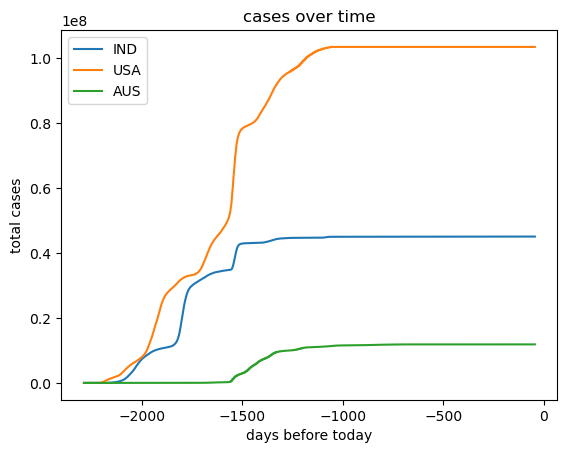

In [37]:
# 3. Plot how **total_cases** for the countries you have picked, grow in time. All three curves 
# have to be on the same plot with the horizontal axis of "Number of days before today". Don't 
# forget the legend. (**4 marks**)
#
# INSERT YOUR CODE HERE
plt.figure()

for c in country_list:
    mask = data_dict['code'] == c
    
    dates = data_dict['date'][mask]
    cases = data_dict['total_cases'][mask]
    
    # convert dates
    days = [convert_date(d) for d in dates]
    
    plt.plot(days, cases, label=c)

plt.xlabel("days before today")
plt.ylabel("total cases")
plt.title("cases over time")
plt.legend()
plt.show()

In [38]:
# 4. If you have chosen the countries appropriately, you will see that the plot you have produced 
# is not very informative. Why is it so? What can you do to make it more informative and to reveal
# the true dynamics? Note there are **two** reasons, you need to provide both. (**1 mark**)
#
# The plot is not very clear because countries have very different population sizes.
# Also the values grow very fast, so small changes are not visible.
# We can fix this by normalizing the data or using log scale.


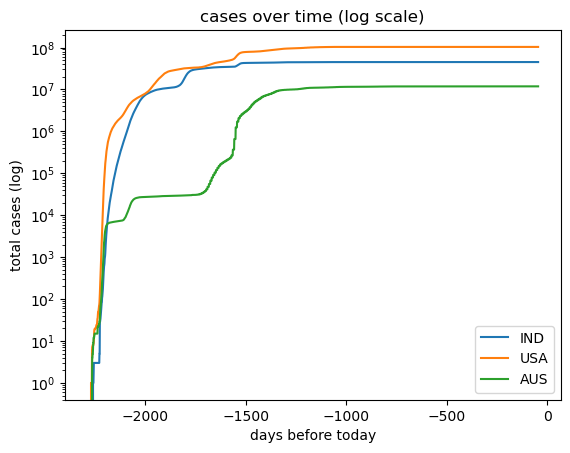

In [39]:
# 5. Implement the idea from Task 4 and make a plot, similar to task 3. (**4 marks**)
#
# INSERT YOUR CODE HERE
plt.figure()

for c in country_list:
    mask = data_dict['code'] == c
    
    dates = data_dict['date'][mask]
    cases = data_dict['total_cases'][mask]
    
    days = [convert_date(d) for d in dates]
    
    plt.plot(days, cases, label=c)

plt.yscale('log')   # main change

plt.xlabel("days before today")
plt.ylabel("total cases (log)")
plt.title("cases over time (log scale)")
plt.legend()
plt.show()


In [40]:
# 6. Explain what you see in the new plot. Do you see specific regions of interest in the 
# epidemic curves? Discuss them. (**4 marks**)
#
# INSERT YOUR COMMENT HERE
#
# In the new plot we can see the growth more clearly.
# At the beginning cases increase slowly, then there is rapid growth.
# After that the curve becomes flatter, which shows control of the spread.
# Different countries show different patterns depending on their response.

---
## **Instruction 6** (HD/GE level)
In this part of the assignment, we go back to the current state of affairs with COVID and look deeper into the dependencies between the parameters of the COVID epidemic and population parameters. We get back to the dataset we have created, namely **data_filtered_by_date**. This dataset also contains population parameters, for example, population and population density, median age, GDP per capita, human development index, and so on.

NOTE: If you are curious, you may want to limit the number of countries you plot by some condition (similar to what we did above by limiting countries to ones with population above 1 million. The mark will not be affected if you don't.

1. First of all, let's confirm what we saw before in Instructions 3 and 4, namely, counterintuitvely weak or no dependence of the number of cases and mortality on average population density. You need to plot two scatter plots of total mortality and total case numbers per million on population density. Take logarithm base 10 of the population density. (**2 marks**)
2. Annotate the scatter plots with the iso codes of countries. (**1 mark**)
3. Discuss the results you can see in the scatter plots. (**2 marks**) 
4. Make scatter plots of the mortality and case numbers on GDP per capita. (**2 marks**)
5. Annotate the scatter plots with the iso codes of countries. (**1 mark**)
6. Discuss what you see in these scatter plots. Strange, isn't it? What do you think are the reasons? There can be many. (**2 marks**)
7. Make and annotate scatter plot of median age vs mortality and meadian age vs log10 of gdp per capita. (**1 mark**)
8. Use numpy **polyfit** or **polynomial** function to fit a straight line in the last scatter plot (median age vs gdp per capita. Overplot the line. Note - IT CAN BE HARD! (**2 marks**)
9. Discuss the last scatter plots. (**2 marks**)

[**Total mark: 15**]

/var/folders/2s/6nsh406909sbmhsdcmr6xxtr0000gn/T/ipykernel_6569/900040402.py:21: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(density)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/transforms.py:354: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy s

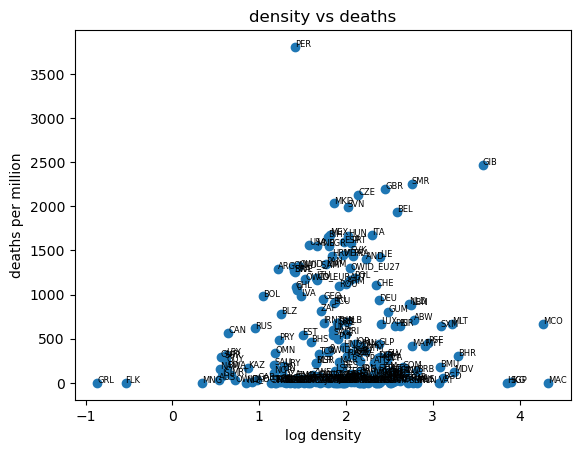

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


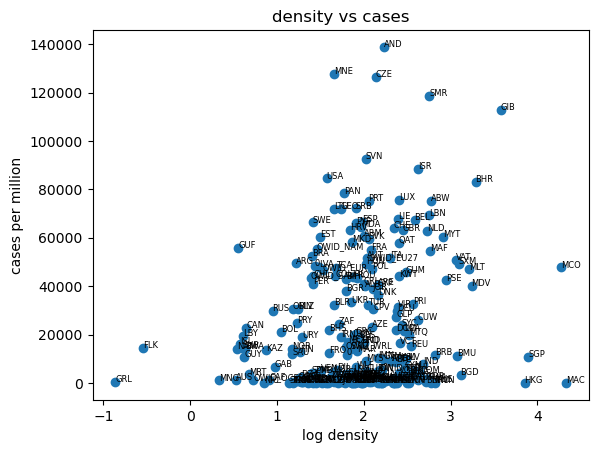

In [41]:
# 1. First of all, let's confirm what we saw before in Instructions 3 and 4, namely, 
# counterintuitvely weak or no dependence of the number of cases and mortality on average 
# population density. You need to plot two scatter plots of total mortality and total 
# case numbers per million on population density. Take logarithm base 10 of the population 
# density. (**2 marks**)
# 2. Annotate the scatter plots with the iso codes of countries. (**1 mark**)

# INSERT YOUR CODE HERE
density = data_filtered_by_date['population_density']
deaths = data_filtered_by_date['total_deaths_per_million']
cases = data_filtered_by_date['total_cases_per_million']
codes = data_filtered_by_date['code']

# remove missing
ok = ~np.isnan(density)
density = density[ok]
deaths = deaths[ok]
cases = cases[ok]
codes = codes[ok]

log_density = np.log10(density)

# mortality plot
plt.figure()
plt.scatter(log_density, deaths)

for i in range(len(codes)):
    plt.text(log_density[i], deaths[i], codes[i], fontsize=6)

plt.xlabel("log density")
plt.ylabel("deaths per million")
plt.title("density vs deaths")
plt.show()

# cases plot
plt.figure()
plt.scatter(log_density, cases)

for i in range(len(codes)):
    plt.text(log_density[i], cases[i], codes[i], fontsize=6)

plt.xlabel("log density")
plt.ylabel("cases per million")
plt.title("density vs cases")
plt.show()

In [42]:
# 3. Discuss what you see in the scatter plots. (**2 mark**)
#
# INSERT YOUR COMMENT HERE
# 
# There is no clear relationship between population density and deaths or cases.
# Some dense countries have low deaths, while some less dense countries have high deaths.
# So density alone does not explain the spread.

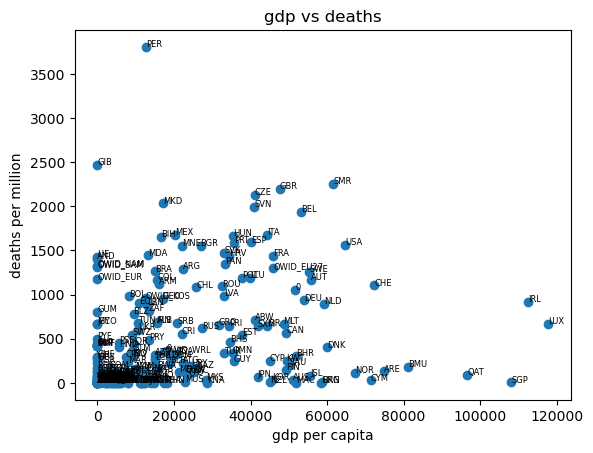

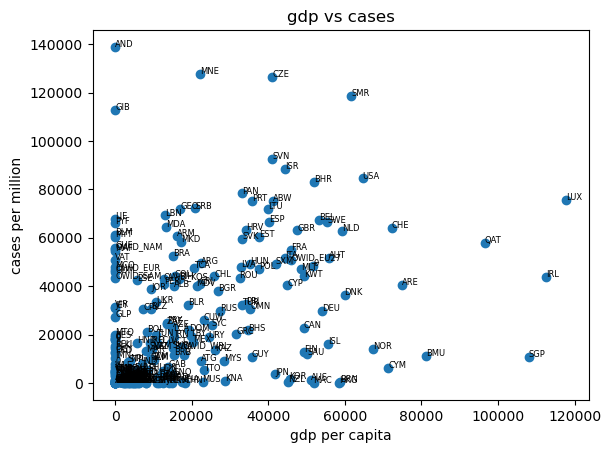

In [43]:
# 4. Make scatter plots of the mortality and case numbers on GDP per capita. (**2 marks**)
# 5. Annotate the scatter plots with the iso codes of countries. (**1 mark**)
# INSERT YOUR CODE HERE
gdp = data_filtered_by_date['gdp_per_capita']

ok = ~np.isnan(gdp)
gdp = gdp[ok]
deaths2 = deaths[ok]
cases2 = cases[ok]
codes2 = codes[ok]

# deaths vs gdp
plt.figure()
plt.scatter(gdp, deaths2)

for i in range(len(codes2)):
    plt.text(gdp[i], deaths2[i], codes2[i], fontsize=6)

plt.xlabel("gdp per capita")
plt.ylabel("deaths per million")
plt.title("gdp vs deaths")
plt.show()

# cases vs gdp
plt.figure()
plt.scatter(gdp, cases2)

for i in range(len(codes2)):
    plt.text(gdp[i], cases2[i], codes2[i], fontsize=6)

plt.xlabel("gdp per capita")
plt.ylabel("cases per million")
plt.title("gdp vs cases")
plt.show()

In [44]:
# 6. Discuss what you see in these scatter plots. Strange, isn't it? What do you think are 
# the reasons? There can be many. (**2 marks**)
#
# INSERT YOUR COMMENT HERE
# 
# Higher GDP countries seem to have higher reported cases and deaths.
# This may be because of better testing and reporting.
# Also older population and lifestyle factors may affect results.

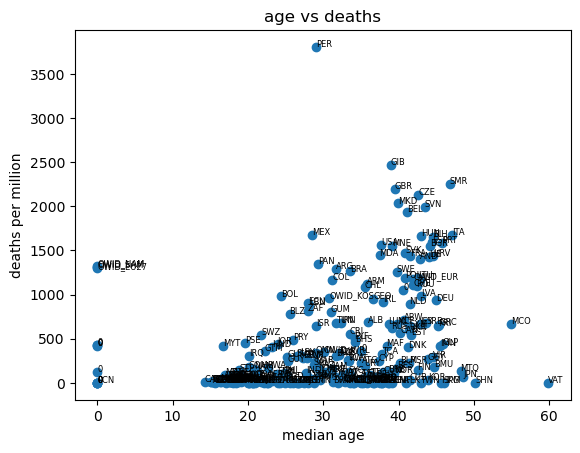

/var/folders/2s/6nsh406909sbmhsdcmr6xxtr0000gn/T/ipykernel_6569/2138874960.py:26: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(age, np.log10(gdp3))
/var/folders/2s/6nsh406909sbmhsdcmr6xxtr0000gn/T/ipykernel_6569/2138874960.py:29: RuntimeWarning: divide by zero encountered in log10
  plt.text(age[i], np.log10(gdp3[i]), codes3[i], fontsize=6)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be fini

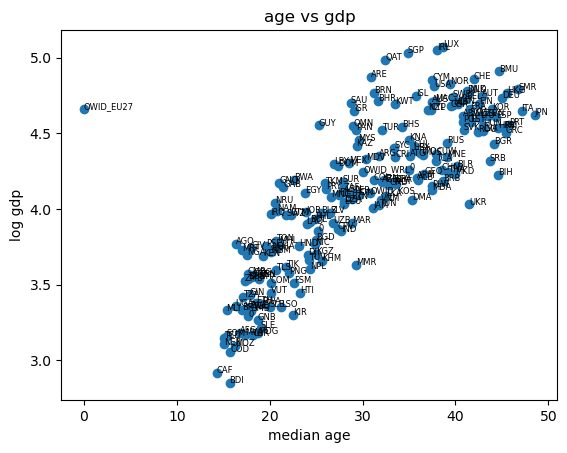

/var/folders/2s/6nsh406909sbmhsdcmr6xxtr0000gn/T/ipykernel_6569/2138874960.py:41: RuntimeWarning: divide by zero encountered in log10
  m, b = np.polyfit(age, np.log10(gdp3), 1)
/var/folders/2s/6nsh406909sbmhsdcmr6xxtr0000gn/T/ipykernel_6569/2138874960.py:47: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(age, np.log10(gdp3))


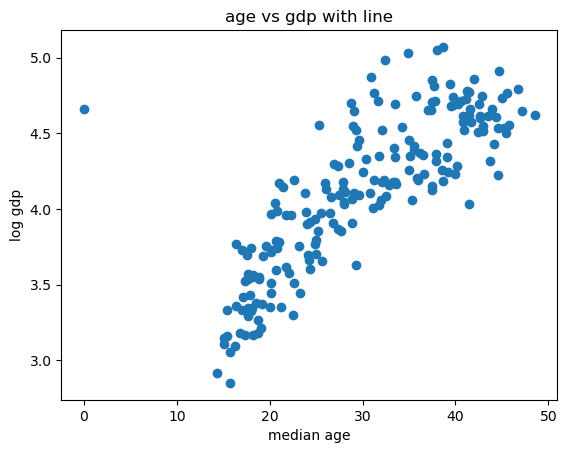

In [45]:
# 7. Make and annotate scatter plot of median age vs mortality and meadian age vs gdp per capita. 
# Use log10 if it makes plot clearer. (**1 mark**)
# INSERT YOUR CODE HERE
age = data_filtered_by_date['median_age']

ok = ~np.isnan(age)
age = age[ok]
deaths3 = deaths[ok]
gdp3 = gdp[ok]
codes3 = codes[ok]

# age vs deaths
plt.figure()
plt.scatter(age, deaths3)

for i in range(len(codes3)):
    plt.text(age[i], deaths3[i], codes3[i], fontsize=6)

plt.xlabel("median age")
plt.ylabel("deaths per million")
plt.title("age vs deaths")
plt.show()

# age vs gdp (log)
plt.figure()
plt.scatter(age, np.log10(gdp3))

for i in range(len(codes3)):
    plt.text(age[i], np.log10(gdp3[i]), codes3[i], fontsize=6)

plt.xlabel("median age")
plt.ylabel("log gdp")
plt.title("age vs gdp")
plt.show()
    

# 8. Use numpy polyfit function to fit a straight line in the last scatter plot (median age vs gdp per 
# capita. Overplot the line. (**2 marks**)
# INSERT YOUR CODE HERE
# fit line
m, b = np.polyfit(age, np.log10(gdp3), 1)

x = age
y = m*x + b

plt.figure()
plt.scatter(age, np.log10(gdp3))
plt.plot(x, y)

plt.xlabel("median age")
plt.ylabel("log gdp")
plt.title("age vs gdp with line")
plt.show()


In [46]:
# 9. Discuss the last scatter plots. (**2 marks**)
#
# INSERT YOUR COMMENT HERE
#
# Countries with higher median age tend to have higher GDP.
# Also higher age is related to higher mortality.
# This shows older populations are more vulnerable.